# **Adaptive Study Planner: From Learning History to Personalized Study Decisions**

## Project overview

This project builds an end-to-end adaptive study planner using the ASSISTments 2009-2010 Skill Builder data. I model a student's chronological learning history with a Transformer-based knowledge-tracing model. The model estimates the probability that the student will answer a candidate skill correctly, and those estimates are then combined with practical constraints such as deadlines, importance, review recency, and available study time to build a study planner.


**Skills demonstrated:** Python, pandas, NumPy, PyTorch, Transformer encoders, sequential modeling, binary classification, probability evaluation, model inference, data visualization

**Motivation:** Students, including myself, often need a useful study assistant that translates learning history into a decision about "what to do to succeed academically," especially when the student has limited time and multiple deadlines.

**Goal:** Build a deep-learning project that uses a Transformer to learn from sequential behavior.

**Main result:** The Transformer knowledge tracer performs better than two non-personalized baselines on both validation and held-out test students. The completed pipeline also generates a valid 90-minute personalized study plan from a held-out student's history.


### Notebook outline

1. Set up and explore the ASSISTments dataset
2. Define the Transformer knowledge-tracing model
3. Train the model and compare
4. Convert model predictions into a student skill profile
5. Finalize the full adaptive planner

## 1. Setup
This project uses the ASSISTments 2009-2010 Skill Builder dataset, which contains student interactions with information such as student ID, problem ID, correctness, skill, problem type, and interaction order.


In [ ]:
%pip install -q gdown
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 6.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 4.0 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
  DEVICE = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
  DEVICE = torch.device("mps")

else:
  DEVICE = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch version: 2.12.1
Device: mps


In [ ]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"

DATA_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: /Users/miookuma/Downloads
Data directory: /Users/miookuma/Downloads/data
Model directory: /Users/miookuma/Downloads/models
Output directory: /Users/miookuma/Downloads/outputs


In [ ]:
import gdown

FILE_ID = "1NNXHFRxcArrU0ZJSb9BIL56vmUt5FhlE"

RAW_DATA_PATH = (DATA_DIR / "assistments_2009_skill_builder_corrected.csv")


if not RAW_DATA_PATH.exists():

    print("Downloading ASSISTments dataset...")

    gdown.download(
        id=FILE_ID,
        output=str(RAW_DATA_PATH),
        quiet=False,
    )

else:

    print("Dataset already exists. Skipping download.")

print("\nSaved to:")
print(RAW_DATA_PATH)

Dataset already exists. Skipping download.

Saved to:
/Users/miookuma/Downloads/data/assistments_2009_skill_builder_corrected.csv


In [ ]:
df_raw = pd.read_csv(
    RAW_DATA_PATH,
    encoding="cp1252",
    low_memory=False,
)

print("Dataset shape:")
print(df_raw.shape)

print("\nColumns:")
for column in df_raw.columns:
    print(f"  - {column}")

display(df_raw.head())

Dataset shape:
(346860, 31)

Columns:
  - Unnamed: 0
  - order_id
  - assignment_id
  - user_id
  - assistment_id
  - problem_id
  - original
  - correct
  - attempt_count
  - ms_first_response
  - tutor_mode
  - answer_type
  - sequence_id
  - student_class_id
  - position
  - type
  - base_sequence_id
  - skill_id
  - skill_name
  - teacher_id
  - school_id
  - hint_count
  - hint_total
  - overlap_time
  - template_id
  - answer_id
  - answer_text
  - first_action
  - bottom_hint
  - opportunity
  - opportunity_original


,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,5,35450311,220674,70363,33196,51481,1,0,14,19813,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


This is an example of the information recorded for each student in the dataset.


In [ ]:
print("Number of rows:")
print(len(df_raw))

print("\nNumber of students:")
print(df_raw["user_id"].nunique())

print("\nCorrectness distribution:")
print(df_raw["correct"].value_counts(dropna=False).sort_index())

print("\nMissing values in important columns:")

important_columns = [
    "order_id",
    "user_id",
    "problem_id",
    "correct",
    "skill_id",
    "skill_name",
]

for column in important_columns:

    if column in df_raw.columns:

        missing = df_raw[column].isna().sum()

        print(
            f"{column:15s}: "
            f"{missing:8d} "
            f"({missing / len(df_raw):.2%})"
        )

print("\nUnique skills:")
print(df_raw["skill_id"].nunique())

print("\nExample skill names:")

display(
    df_raw[
        ["skill_id", "skill_name"]
    ]
    .dropna()
    .drop_duplicates()
    .head(20)
)

Number of rows:
346860

Number of students:
4217

Correctness distribution:
correct
0    123042
1    223818
Name: count, dtype: int64

Missing values in important columns:
order_id       :        0 (0.00%)
user_id        :        0 (0.00%)
problem_id     :        0 (0.00%)
correct        :        0 (0.00%)
skill_id       :    63755 (18.38%)
skill_name     :    72270 (20.84%)

Unique skills:
149

Example skill names:


,skill_id,skill_name
0,1_13,Box and Whisker
4,1_15,Box and Whisker
160,1,Box and Whisker
3957,2_37_70,Circle Graph
3963,2_37_48_77,Circle Graph
3964,2_48_79,Circle Graph
3965,2_37_48,Circle Graph
3969,2_70,Circle Graph
10165,4,Histogram as Table or Graph
11969,5_375,Number Line


In this dataset, we have 346,860 interactions from 4,212 students with 149 unique skills. Some values in the dataset are missing, but it contains both correct and incorrect responses.


## 2. Clean data structure
Before choosing the model input, I inspect the structure of the dataset and drop some missing values.


In [ ]:
df = df_raw.copy()

# "Unnamed: 0" is only the old saved DataFrame index.
# It contains no learning information.
df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)

print("Raw shape:    ", df_raw.shape)
print("Working shape:", df.shape)

Raw shape:     (346860, 31)
Working shape: (346860, 30)


In [ ]:
def split_skill_ids(value):
    if pd.isna(value):
        return []

    return [
        part.strip()
        for part in str(value).split("_")
        if part.strip()
    ]

skill_missing_status = pd.DataFrame({
    "skill_id_missing": df["skill_id"].isna(),
    "skill_name_missing": df["skill_name"].isna(),
})

print("Missing-skill combinations:")

display(
    skill_missing_status
    .value_counts()
    .rename("rows")
    .reset_index()
)

skill_id_text = df["skill_id"].astype("string")

multi_skill_mask = skill_id_text.str.contains(
    "_",
    regex=False,
    na=False,
)

print(
    "\nRows with one skill-ID string:",
    (~multi_skill_mask & df["skill_id"].notna()).sum(),
)

print(
    "Rows with multiple skill IDs:",
    multi_skill_mask.sum(),
)

atomic_skill_ids = {
    skill
    for value in df["skill_id"].dropna()
    for skill in split_skill_ids(value)
}

print(
    "\nUnique raw skill_id strings:",
    df["skill_id"].nunique()
)

print(
    "Unique atomic skill IDs:",
    len(atomic_skill_ids)
)

print("\nExamples of multi-skill interactions:")

display(
    df.loc[
        multi_skill_mask,
        [
          "skill_id",
          "skill_name",
          "problem_id",
          "correct",
        ],
    ]
    .drop_duplicates()
    .head(20)
)

Missing-skill combinations:


,skill_id_missing,skill_name_missing,rows
0,False,False,274590
1,True,True,63755
2,False,True,8515



Rows with one skill-ID string: 236068
Rows with multiple skill IDs: 47037

Unique raw skill_id strings: 149
Unique atomic skill IDs: 123

Examples of multi-skill interactions:


,skill_id,skill_name,problem_id,correct
0,1_13,Box and Whisker,51424,1
1,1_13,Box and Whisker,51435,1
2,1_13,Box and Whisker,51444,0
3,1_13,Box and Whisker,51395,1
4,1_15,Box and Whisker,51481,0
5,1_15,Box and Whisker,51457,1
6,1_15,Box and Whisker,51459,1
7,1_13,Box and Whisker,51408,1
8,1_15,Box and Whisker,51453,1
9,1_13,Box and Whisker,51397,1


Some rows involve multiple skills. I modify the representation of composite `skill_id` and `skill_name` values so the model handles these cases consistently.


In [ ]:
skill_pairs = (
    df[["skill_id", "skill_name"]].dropna().drop_duplicates()
)

print(
    "Unique skill_id strings:",
    skill_pairs["skill_id"].nunique()
)

print(
    "Unique skill names:",
    skill_pairs["skill_name"].nunique()
)

ids_per_name = (
    skill_pairs
    .groupby("skill_name")["skill_id"].nunique().sort_values(ascending=False)
)

print("\nSkill names associated with the most ID strings:")

display(
    ids_per_name
    .head(20).rename("number_of_skill_id_strings").to_frame()
)

names_per_id = (
    skill_pairs
    .groupby("skill_id")["skill_name"].nunique().sort_values(ascending=False)
)

print(
    "\nNumber of skill-ID strings associated "
    "with more than one skill name:"
)

print(
    (names_per_id > 1).sum()
)

display(
    names_per_id[
        names_per_id > 1
    ]
    .head(20)
    .rename("number_of_skill_names")
    .to_frame()
)

Unique skill_id strings: 138
Unique skill names: 101

Skill names associated with the most ID strings:


,number_of_skill_id_strings
skill_name,
Table,8
Circle Graph,5
Unit Conversion Within a System,4
Stem and Leaf Plot,4
Equivalent Fractions,3
Box and Whisker,3
Number Line,2
Addition Whole Numbers,2
Pythagorean Theorem,2



Number of skill-ID strings associated with more than one skill name:
0


,number_of_skill_names
skill_id,


This shows that multiple raw ID strings can share the same human-readable skill name, while no observed ID string maps to multiple names in this table. So for the final model, I use `skill_name` as the learning-concept representation to avoid confusing the planner.


In [ ]:
print("Answer types:")

display(
    df["answer_type"]
    .value_counts(dropna=False).rename("rows").to_frame()
)

print("\nCorrectness by answer type:")

display(
    pd.crosstab(
        df["answer_type"],
        df["correct"],
        margins=True,
    )
)

print("\nMain vs scaffolding problems:")

display(
    pd.crosstab(
        df["original"],
        df["correct"],
        margins=True,
    )
)

Answer types:


,rows
answer_type,
algebra,270780
choose_1,41181
fill_in_1,34786
choose_n,105
open_response,8



Correctness by answer type:


correct,0,1,All
answer_type,,,
algebra,99499,171281,270780
choose_1,9347,31834,41181
choose_n,54,51,105
fill_in_1,14134,20652,34786
open_response,8,0,8
All,123042,223818,346860



Main vs scaffolding problems:


correct,0,1,All
original,,,
0,28937,42465,71402
1,94105,181353,275458
All,123042,223818,346860


This shows some additional information in the dataset. These fields provide more detail about the problems each student solves easily or with difficulty.


### 2.1 Prediction target and repeated interactions
The prediction target is binary correctness. I also distinguish original main problems from scaffolding problems. 

In [ ]:
print(
    "Duplicated order_id values:",
    df["order_id"].duplicated().sum()
)

duplicate_student_problem = df.duplicated(
    subset=[
        "user_id",
        "problem_id",
    ],
    keep=False,
)

print(
    "Rows belonging to repeated (student, problem) pairs:",
    duplicate_student_problem.sum()
)

if duplicate_student_problem.any():

    display(
        df.loc[
          duplicate_student_problem,
          [
            "user_id",
            "problem_id",
            "order_id",
            "skill_id",
            "skill_name",
            "correct",
          ],
        ]
        .sort_values(
            ["user_id", "order_id"]
        )
        .head(30)
    )

Duplicated order_id values: 0
Rows belonging to repeated (student, problem) pairs: 9378


,user_id,problem_id,order_id,skill_id,skill_name,correct
19564,53167,57051,26451283,10_14,Table,1
108195,53167,53613,26452685,58_85,Addition Whole Numbers,1
108198,53167,53613,32513894,58_85,Addition Whole Numbers,1
19569,53167,57051,35128429,10_14,Table,1
200344,64525,54193,21443359,279,Multiplication and Division Integers,1
196015,64525,54035,21443836,278,Addition and Subtraction Positive Decimals,1
108207,64525,49286,28177219,58,Addition Whole Numbers,1
144049,64525,109008,28178426,77,Finding Percents,0
283154,64525,109010,28178478,NaN,NaN,1
144052,64525,109011,28178736,77,Finding Percents,1


Also, I make the model not treat repeated `(student, problem)` pairs as duplicate rows if `order_id` is unique, so repeated attempts can represent distinct information in a student's learning history.


In [ ]:
skill_id_clean = (
    df["skill_id"]
    .astype("string").str.strip()
)

has_known_skill = (
    skill_id_clean.notna()
    & skill_id_clean.ne("")
    & skill_id_clean.str.lower().ne("noskill")
)

answer_type_clean = (
    df["answer_type"]
    .astype("string").str.strip().str.lower()
)

not_open_response = (
    answer_type_clean.ne("open_response")
    .fillna(True)
)

main_problem = (
    df["original"] == 1
)

candidate_target_mask = (
    has_known_skill
    & not_open_response
    & main_problem
)

candidate_targets = df.loc[
    candidate_target_mask
].copy()


print("Original rows:", len(df))

print("Potential prediction-target rows:", len(candidate_targets))

print("Students represented:", candidate_targets["user_id"].nunique())

print("\nRows removed for missing skill:", (~has_known_skill).sum())

print("Rows removed because open_response:", (~not_open_response).sum())

print("Rows that are scaffolding problems:", (~main_problem).sum())

print("\nCandidate target sequence lengths:")

display(
    candidate_targets
    .groupby("user_id")
    .size()
    .describe(
        percentiles=[
          0.05,
          0.10,
          0.25,
          0.50,
          0.75,
          0.90,
          0.95,
          0.99,
        ]
    )
)

Original rows: 346860
Potential prediction-target rows: 259391
Students represented: 4163

Rows removed for missing skill: 63755
Rows removed because open_response: 8
Rows that are scaffolding problems: 71402

Candidate target sequence lengths:


count    4163.000000
mean       62.308672
std       117.611875
min         1.000000
5%          2.000000
10%         3.000000
25%         8.000000
50%        19.000000
75%        55.000000
90%       150.000000
95%       314.000000
99%       599.040000
max       963.000000
dtype: float64

## 3. Organize dataset for model
I now organize and create the event table used by the model. I keep interactions with a known skill name, binary correctness, and a non-open-response answer type. This leaves a modified dataset of 274,592 learning events across 4,151 students and 101 named skills.


In [ ]:
events = df.copy()

events["skill_name"] = (
    events["skill_name"]
    .astype("string").str.strip()
)

# Treat empty strings as missing
events.loc[
    events["skill_name"].eq(""),
    "skill_name"
] = pd.NA

events["answer_type"] = (
    events["answer_type"]
    .astype("string").str.strip().str.lower()
)

usable_event_mask = (
    events["skill_name"].notna()
    & events["correct"].isin([0, 1])
    & events["answer_type"].ne("open_response")
)

events = events.loc[usable_event_mask].copy()

print("Usable learning events:", len(events))
print("Students:", events["user_id"].nunique())
print("Skills:", events["skill_name"].nunique())

Usable learning events: 274582
Students: 4151
Skills: 101


A key design choice is to keep scaffolding interactions as historical context but predict correctness only on main problems because a scaffold can contain evidence about what the student recently practiced.

In [ ]:
events["is_main_problem"] = (events["original"] == 1)

events["is_scaffold"] = (events["original"] == 0)

events["is_target"] = events["is_main_problem"]

print("Usable history events:")
print(len(events))

print("\nMain-problem prediction targets:")
print(events["is_target"].sum())

print("\nScaffolding events kept as context:")
print(events["is_scaffold"].sum())

display(
    pd.crosstab(
        events["is_scaffold"],
        events["correct"],
        margins=True,
    )
)

Usable history events:
274582

Main-problem prediction targets:
251397

Scaffolding events kept as context:
23185


correct,0,1,All
is_scaffold,,,
False,85053,166344,251397
True,7834,15351,23185
All,92887,181695,274582


In [ ]:
events = (
    events
    .sort_values(
        ["user_id", "order_id"]
    )
    .reset_index(drop=True)
)

events["event_position"] = (
    events
    .groupby("user_id")
    .cumcount()
)

print("First student's chronological history:")

first_student = events["user_id"].iloc[0]

display(
    events.loc[
      events["user_id"] == first_student,
      [
        "user_id",
        "event_position",
        "order_id",
        "skill_name",
        "correct",
        "is_scaffold",
        "is_target",
      ],
    ]
    .head(20)
)

First student's chronological history:


,user_id,event_position,order_id,skill_name,correct,is_scaffold,is_target
0,14,0,21617623,Circle Graph,0,False,True
1,14,1,21617632,Circle Graph,1,False,True
2,14,2,21617641,Circle Graph,0,False,True
3,14,3,21617650,Circle Graph,0,False,True
4,14,4,21617659,Circle Graph,0,False,True
5,14,5,21617667,Circle Graph,0,False,True
6,14,6,21617675,Circle Graph,0,False,True
7,14,7,21617692,Circle Graph,0,False,True
8,14,8,21617731,Circle Graph,1,False,True
9,14,9,21617749,Circle Graph,0,False,True


The events are sorted by `user_id` and `order_id`, then assigned a position within each student's history. It is important to make every prediction use only the interactions that occurred before the target event. 

In [ ]:
skill_counts = (events["skill_name"].value_counts())

print("Skill frequency statistics:")

display(
    skill_counts.describe(
      percentiles=[
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
      ]
    )
)

print("\n20 least common skills:")

display(
    skill_counts
    .sort_values()
    .head(20)
    .rename("interactions")
    .to_frame()
)

print("\n20 most common skills:")

display(
    skill_counts
    .head(20)
    .rename("interactions")
    .to_frame()
)

Skill frequency statistics:


count          101.0
mean     2718.633663
std      3792.877261
min              5.0
5%              21.0
10%             47.0
25%            288.0
50%           1477.0
75%           3890.0
90%           6611.0
95%           8068.0
max          24253.0
Name: count, dtype: Float64


20 least common skills:


,interactions
skill_name,
Reading a Ruler or Scale,5
Finding Slope from Ordered Pairs,5
Recognize Quadratic Pattern,8
Finding Slope From Situation,9
Distributive Property,18
Equivalent Fractions,21
Quadratic Formula to Solve Quadratic Equation,32
Midpoint,32
Interpreting Coordinate Graphs,33



20 most common skills:


,interactions
skill_name,
Equation Solving Two or Fewer Steps,24253
Conversion of Fraction Decimals Percents,18742
Addition and Subtraction Integers,12741
Addition and Subtraction Fractions,11334
Equation Solving More Than Two Steps,8115
Proportion,8068
Subtraction Whole Numbers,7669
Ordering Positive Decimals,7317
Multiplication and Division Integers,7058


This shows the least and most common skills appearing in the interactions. "Equation Solving Two or Fewer Steps" is the most common, while "Finding Slope from Ordered Pairs" is the least common.


### 3.1 Split the samples
I split the data rows by student for the model instead of using a random row-level split, since many rows belong to the same students. I use about 80% for training, 10% for validation, and 10% for test at the student level. This creates 3,320 training students, 415 validation students, and 416 test students before filtering. All events from one student stay in a single split.


In [ ]:
rng = np.random.default_rng(SEED)

student_ids = (events["user_id"].unique().copy())

rng.shuffle(student_ids)

n_students = len(student_ids)

n_train = int(0.80 * n_students)
n_val = int(0.10 * n_students)

train_students = set(student_ids[:n_train])

val_students = set(
    student_ids[
        n_train:n_train + n_val
    ]
)

test_students = set(
    student_ids[
        n_train + n_val:
    ]
)

events["split"] = "test"

events.loc[
    events["user_id"].isin(train_students),
    "split"
] = "train"

events.loc[
    events["user_id"].isin(val_students),
    "split"
] = "val"


print("Students per split:")

display(
    events[
        ["user_id", "split"]
    ]
    .drop_duplicates()
    ["split"]
    .value_counts()
)


print("\nEvents per split:")

display(
    events["split"]
    .value_counts()
)


print("\nPrediction targets per split:")

display(
    events.loc[
        events["is_target"],
        "split"
    ]
    .value_counts()
)

Students per split:


split
train    3320
test      416
val       415
Name: count, dtype: int64


Events per split:


split
train    226806
val       23998
test      23778
Name: count, dtype: int64


Prediction targets per split:


split
train    207141
val       22357
test      21899
Name: count, dtype: int64

In [ ]:
train_users = set(
    events.loc[
        events["split"] == "train",
        "user_id"
    ]
)

val_users = set(
    events.loc[
        events["split"] == "val",
        "user_id"
    ]
)

test_users = set(
    events.loc[
        events["split"] == "test",
        "user_id"
    ]
)

assert train_users.isdisjoint(val_users)
assert train_users.isdisjoint(test_users)
assert val_users.isdisjoint(test_users)

print("✓ No student overlap between splits.")

train_skills = set(
    events.loc[
        events["split"] == "train",
        "skill_name"
    ]
)

val_skills = set(
    events.loc[
        events["split"] == "val",
        "skill_name"
    ]
)

test_skills = set(
    events.loc[
        events["split"] == "test",
        "skill_name"
    ]
)

unseen_val_skills = val_skills - train_skills
unseen_test_skills = test_skills - train_skills


print(
    "Validation skills unseen in training:",
    unseen_val_skills
)

print(
    "Test skills unseen in training:",
    unseen_test_skills
)

✓ No student overlap between splits.
Validation skills unseen in training: set()
Test skills unseen in training: set()


This confirms that there is no student overlap. Validation and test also contain no skill names that are completely absent from training, so evaluation focuses on generalizing to new students rather than unseen skills.


### 3.2 Filter the samples
I require each modeled skill to have at least 50 training events, including at least 10 correct and 10 incorrect responses to avoid evaluating probabilities with weak evidence. 

In [ ]:
MIN_TRAIN_SKILL_EVENTS = 50
MIN_TRAIN_PER_CLASS = 10

train_skill_stats = (
    events.loc[
        events["split"] == "train"
    ]
    .groupby("skill_name")
    .agg(
        train_events=("correct", "size"),
        train_correct=("correct", "sum"),
    )
)

train_skill_stats["train_incorrect"] = train_skill_stats["train_events"] - train_skill_stats["train_correct"]

supported_skill_mask = (
    (train_skill_stats["train_events"] >= MIN_TRAIN_SKILL_EVENTS)
    &
    (train_skill_stats["train_correct"] >= MIN_TRAIN_PER_CLASS)
    &
    (train_skill_stats["train_incorrect"] >= MIN_TRAIN_PER_CLASS)
)

supported_skills = sorted(
    train_skill_stats.index[
        supported_skill_mask
    ].tolist()
)

excluded_skills = (
    train_skill_stats.loc[
        ~supported_skill_mask
    ]
    .sort_values("train_events")
)

print(
    "Total skills:",
    len(train_skill_stats)
)

print(
    "Supported skills:",
    len(supported_skills)
)

print(
    "Excluded low-data skills:",
    len(excluded_skills)
)

print("\nExcluded skills:")

display(excluded_skills)

Total skills: 101
Supported skills: 89
Excluded low-data skills: 12

Excluded skills:


,train_events,train_correct,train_incorrect
skill_name,,,
Finding Slope from Ordered Pairs,1,0,1
Finding Slope From Situation,4,0,4
Reading a Ruler or Scale,4,0,4
Recognize Quadratic Pattern,8,5,3
Distributive Property,14,13,1
Equivalent Fractions,16,5,11
Interpreting Coordinate Graphs,27,15,12
Quadratic Formula to Solve Quadratic Equation,27,2,25
Midpoint,29,18,11


In [ ]:
model_events = (
    events.loc[
      events["skill_name"].isin(supported_skills)
    ]
    .copy()
)

PAD_SKILL = 0

skill_to_idx = {
    skill: idx + 1
    for idx, skill
    in enumerate(supported_skills)
}

idx_to_skill = {
    idx: skill
    for skill, idx
    in skill_to_idx.items()
}

NUM_SKILLS = len(skill_to_idx)

model_events["skill_idx"] = (
    model_events["skill_name"]
    .map(skill_to_idx)
    .astype("int64")
)

model_events["response_idx"] = (
    model_events["correct"]
    .astype("int64") + 1
)

model_events["type_idx"] = np.where(
    model_events["is_scaffold"],
    2,
    1,
).astype("int64")

model_events = (
    model_events
    .sort_values(
        ["user_id", "order_id"]
    )
    .reset_index(drop=True)
)

model_events["model_event_position"] = (
    model_events
    .groupby("user_id")
    .cumcount()
)

print(
    "Final model events:",
    len(model_events)
)

print(
    "Students:",
    model_events["user_id"].nunique()
)

print(
    "Modeled skills:",
    NUM_SKILLS
)

print(
    "Prediction targets:",
    model_events["is_target"].sum()
)

Final model events: 274221
Students: 4138
Modeled skills: 89
Prediction targets: 251042


After filtering, the model will use 89 skills, 274,221 chronological events, and 251,042 main problem targets. 

## 4. Build learning-history samples
For each prediction target, the model receives the student's recent interaction history and the identity of the skill. It must predict the target correctness without seeing the target response itself.

In [ ]:
MAX_HISTORY = 100
MIN_HISTORY = 5

student_model_lengths = (
    model_events
    .groupby("user_id")
    .size()
)

print("Model-ready interactions per student:")

display(
  student_model_lengths.describe(
      percentiles=[
          0.10,
          0.25,
          0.50,
          0.75,
          0.90,
          0.95,
          0.99,
       ]
  )
)

print("\nStudents whose full history fits inside 100 events:")

print(f"{(student_model_lengths <= MAX_HISTORY).mean():.2%}")

eligible_target_mask = (
    model_events["is_target"]
    &
    (model_events["model_event_position"] >= MIN_HISTORY)
)

print("\nEligible prediction targets:")

display(
    model_events.loc[
        eligible_target_mask,
        "split"
    ]
    .value_counts()
)

Model-ready interactions per student:


count    4138.000000
mean       66.268971
std       128.232074
min         1.000000
10%         4.000000
25%         8.000000
50%        20.000000
75%        60.000000
90%       154.000000
95%       335.600000
99%       667.000000
max      1039.000000
dtype: float64


Students whose full history fits inside 100 events:
83.49%

Eligible prediction targets:


split
train    191651
val       20442
test      20015
Name: count, dtype: int64

I use a maximum history length of 100 events and require at least 5 previous interactions before creating a prediction sample. Longer histories use only the most recent 100 interactions.


In [ ]:
def build_student_sequences(frame):

    sequences = {}

    for user_id, group in frame.groupby("user_id", sort=False,):

        group = (group.sort_values("order_id").reset_index(drop=True))

        sequences[int(user_id)] = {

            "skill_idx":
                group["skill_idx"]
                .to_numpy(dtype=np.int64),

            "response_idx":
                group["response_idx"]
                .to_numpy(dtype=np.int64),

            "type_idx":
                group["type_idx"]
                .to_numpy(dtype=np.int64),

            "correct":
                group["correct"]
                .to_numpy(dtype=np.float32),

            "is_target":
                group["is_target"]
                .to_numpy(dtype=bool),

            "order_id":
                group["order_id"]
                .to_numpy(dtype=np.int64),
        }

    return sequences

In [ ]:
train_sequences = build_student_sequences(
    model_events.loc[
        model_events["split"] == "train"
    ]
)

val_sequences = build_student_sequences(
    model_events.loc[
        model_events["split"] == "val"
    ]
)

test_sequences = build_student_sequences(
    model_events.loc[
        model_events["split"] == "test"
    ]
)

print("Train students:", len(train_sequences))

print("Validation students:", len(val_sequences))

print("Test students:", len(test_sequences))

Train students: 3310
Validation students: 413
Test students: 415


In [ ]:
def build_sample_index(sequences, min_history=MIN_HISTORY,):
    sample_index = []

    for user_id, seq in sequences.items():

        target_positions = np.flatnonzero(
            seq["is_target"]
        )

        target_positions = target_positions[
            target_positions >= min_history
        ]

        sample_index.extend(
            (
                user_id,
                int(position),
            )
            for position
            in target_positions
        )

    return sample_index

In [ ]:
train_sample_index = build_sample_index(train_sequences)

val_sample_index = build_sample_index(val_sequences)

test_sample_index = build_sample_index(test_sequences)

print("Training samples:", len(train_sample_index))

print("Validation samples:", len(val_sample_index))

print("Test samples:", len(test_sample_index))

Training samples: 191651
Validation samples: 20442
Test samples: 20015


After the modification, there are 3,310 train students with 191,651 samples, 413 validation students with 20,442 samples, and 415 test students with 20,015 samples. 

### 4.1 PyTorch dataset
The history slice ends immediately before the target position, which prevents the target answer from entering the input. Each historical event contains three categorical signals: the skill practiced, correctness, and whether the event was a main problem or scaffold. Also, histories shorter than 100 events are left-padded with zeros.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class KnowledgeTracingDataset(Dataset):

    def __init__(
        self,
        sequences,
        sample_index,
        max_history=100,
    ):

        self.sequences = sequences
        self.sample_index = sample_index
        self.max_history = max_history

    def __len__(self):
        return len(self.sample_index)

    def __getitem__(self, index):
        user_id, target_pos = (self.sample_index[index])

        seq = self.sequences[user_id]

        history_start = max(0, target_pos - self.max_history)

        hist_skill = seq["skill_idx"][history_start:target_pos]

        hist_response = seq["response_idx"][history_start:target_pos]

        hist_type = seq["type_idx"][history_start:target_pos]

        history_length = len(hist_skill)

        pad_length = (self.max_history - history_length)


        hist_skill = np.pad(
            hist_skill,
            (pad_length, 0),
            constant_values=0,
        )

        hist_response = np.pad(
            hist_response,
            (pad_length, 0),
            constant_values=0,
        )

        hist_type = np.pad(
            hist_type,
            (pad_length, 0),
            constant_values=0,
        )


        padding_mask = np.zeros(
            self.max_history,
            dtype=bool,
        )

        padding_mask[
            :pad_length
        ] = True


        target_skill = (seq["skill_idx"][target_pos])

        target_label = (seq["correct"][target_pos])


        return {

            "hist_skill":
                torch.tensor(
                    hist_skill,
                    dtype=torch.long,
                ),

            "hist_response":
                torch.tensor(
                    hist_response,
                    dtype=torch.long,
                ),

            "hist_type":
                torch.tensor(
                    hist_type,
                    dtype=torch.long,
                ),

            "padding_mask":
                torch.tensor(
                    padding_mask,
                    dtype=torch.bool,
                ),

            "target_skill":
                torch.tensor(
                    target_skill,
                    dtype=torch.long,
                ),

            "label":
                torch.tensor(
                    target_label,
                    dtype=torch.float32,
                ),

            "history_length":
                torch.tensor(
                    history_length,
                    dtype=torch.long,
                ),

            "user_id":
                torch.tensor(
                    user_id,
                    dtype=torch.long,
                ),

            "target_position":
                torch.tensor(
                    target_pos,
                    dtype=torch.long,
                ),
        }

In [ ]:
train_dataset = KnowledgeTracingDataset(
    train_sequences,
    train_sample_index,
    MAX_HISTORY,
)

val_dataset = KnowledgeTracingDataset(
    val_sequences,
    val_sample_index,
    MAX_HISTORY,
)

test_dataset = KnowledgeTracingDataset(
    test_sequences,
    test_sample_index,
    MAX_HISTORY,
)

print("Train dataset:", len(train_dataset))

print("Validation dataset:", len(val_dataset))

print("Test dataset:", len(test_dataset))

Train dataset: 191651
Validation dataset: 20442
Test dataset: 20015


The final sample contains 191,651 training, 20,442 validation, and 20,015 test targets. 

In [ ]:
sample = train_dataset[0]

valid_positions = (
    ~sample["padding_mask"]
).numpy()

hist_skills = (
    sample["hist_skill"]
    .numpy()[valid_positions]
)

hist_responses = (
    sample["hist_response"]
    .numpy()[valid_positions]
)

hist_types = (
    sample["hist_type"]
    .numpy()[valid_positions]
)

history_preview = pd.DataFrame({

    "skill": [
        idx_to_skill[int(skill)]
        for skill
        in hist_skills
    ],

    "response": [
        "correct"
        if response == 2
        else "incorrect"
        for response
        in hist_responses
    ],

    "problem_type": [
        "scaffold"
        if interaction_type == 2
        else "main"
        for interaction_type
        in hist_types
    ],
})

print("Student:", sample["user_id"].item())

print("History length:", sample["history_length"].item())

print("\nTARGET SKILL:")

print(
    idx_to_skill[
        sample[
            "target_skill"
        ].item()
    ]
)

print(
    "\nTARGET LABEL:",
    int(
        sample["label"].item()
    )
)

print("\nMost recent history:")

display( history_preview.tail(15))

Student: 14
History length: 5

TARGET SKILL:
Circle Graph

TARGET LABEL: 0

Most recent history:


,skill,response,problem_type
0,Circle Graph,incorrect,main
1,Circle Graph,correct,main
2,Circle Graph,incorrect,main
3,Circle Graph,incorrect,main
4,Circle Graph,incorrect,main


This shows the five previous interactions from an example sample. Each history contains the information needed for prediction.


In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

batch = next(iter(train_loader))

print("History skill shape:", batch["hist_skill"].shape)

print("History response shape:", batch["hist_response"].shape)

print("History type shape:", batch["hist_type"].shape)

print("Padding mask shape:", batch["padding_mask"].shape)

print("Target skill shape:", batch["target_skill"].shape)

print("Labels shape:", batch["label"].shape)

History skill shape: torch.Size([128, 100])
History response shape: torch.Size([128, 100])
History type shape: torch.Size([128, 100])
Padding mask shape: torch.Size([128, 100])
Target skill shape: torch.Size([128])
Labels shape: torch.Size([128])


The DataLoader uses batches of 128 samples and converts each history feature, target skill, and binary label into tensors.


## 5. Transformer knowledge tracer
The central deep-learning component is a query-based Transformer. Instead of making a student's history into one generic score, the same student history can produce different probabilities depending on which skill is being asked about.

Each historical event is represented by the sum of four learned embeddings:
$$
h_t = E_{skill}(s_t) + E_{response}(r_t) + E_{type}(c_t) + E_{position}(t)
$$

A two-layer Transformer encoder contextualizes these events so that each position can represent its relationship to the rest of the student's recent history.

For the skill we want to evaluate, its skill embedding becomes a **query**. Then it asks which parts of the encoded history are most relevant to that candidate skill:
$$
z = \operatorname{MHA}(q, H, H), \qquad q = E_{skill}(s^*).
$$

The query and attended history are combined and passed through a small neural-network head. The model outputs one logit, which becomes a success probability with
$$
P(\text{correct}=1 \mid \text{history}, s^*) = \sigma(\text{logit}).
$$


In [ ]:
import torch.nn as nn

D_MODEL = 64
N_HEADS = 4
NUM_HISTORY_LAYERS = 2
FF_DIM = 128
DROPOUT = 0.10

print("Model configuration:")
print(f"  Number of skills:      {NUM_SKILLS}")
print(f"  Maximum history:       {MAX_HISTORY}")
print(f"  Embedding dimension:   {D_MODEL}")
print(f"  Attention heads:       {N_HEADS}")
print(f"  History layers:        {NUM_HISTORY_LAYERS}")
print(f"  Feed-forward size:     {FF_DIM}")
print(f"  Dropout:               {DROPOUT}")

Model configuration:
  Number of skills:      89
  Maximum history:       100
  Embedding dimension:   64
  Attention heads:       4
  History layers:        2
  Feed-forward size:     128
  Dropout:               0.1


The chosen architecture is moderate rather than oversized. It is large enough to model sequence interactions but still practical to train on limited hardware.


In [ ]:
class AdaptiveKnowledgeTracer(nn.Module):

    def __init__(
        self,
        num_skills,
        max_history,
        d_model=64,
        n_heads=4,
        num_history_layers=2,
        ff_dim=128,
        dropout=0.10,
    ):

        super().__init__()


        self.skill_embedding = nn.Embedding(
            num_embeddings=num_skills + 1,
            embedding_dim=d_model,
            padding_idx=0,
        )

        self.response_embedding = nn.Embedding(
            num_embeddings=3,
            embedding_dim=d_model,
            padding_idx=0,
        )

        self.type_embedding = nn.Embedding(
            num_embeddings=3,
            embedding_dim=d_model,
            padding_idx=0,
        )

        self.position_embedding = nn.Embedding(
            num_embeddings=max_history,
            embedding_dim=d_model,
        )

        self.event_norm = nn.LayerNorm(
            d_model
        )

        self.event_dropout = nn.Dropout(
            dropout
        )


        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.history_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_history_layers,
            enable_nested_tensor=False
        )


        self.query_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.query_norm = nn.LayerNorm(d_model)


        self.predictor = nn.Sequential(
            
          nn.Linear(d_model, ff_dim,),

          nn.GELU(),

          nn.Dropout(dropout),

          nn.Linear(ff_dim,1,),
        )


        self.max_history = max_history
        self.d_model = d_model


    def forward(
        self,
        hist_skill,
        hist_response,
        hist_type,
        padding_mask,
        target_skill,
        return_attention=False,
    ):

        batch_size = (hist_skill.size(0))

        skill_emb = self.skill_embedding(hist_skill)

        response_emb = self.response_embedding(hist_response)

        type_emb = self.type_embedding(hist_type)


        positions = torch.arange(
            self.max_history,
            device=hist_skill.device,
        )

        positions = positions.unsqueeze(0).expand(batch_size, -1)

        position_emb = self.position_embedding(positions)


        history = (
            skill_emb
            + response_emb
            + type_emb
            + position_emb
        )

        history = self.event_norm(history)

        history = self.event_dropout(history)

        # Zero padded locations before Transformer processing.
        history = history.masked_fill(
            padding_mask.unsqueeze(-1),
            0.0,
        )


        encoded_history = self.history_encoder(history, src_key_padding_mask=padding_mask)


        query = self.skill_embedding(target_skill)

        query = query.unsqueeze(1)


        attended_history, attention_weights = (
            self.query_attention(

                query=query,

                key=encoded_history,

                value=encoded_history,

                key_padding_mask=padding_mask,

                need_weights=return_attention,

                average_attn_weights=False,
            )
        )


        student_skill_state = self.query_norm(
            query + attended_history
        )

        # Remove the sequence dimension of length 1.
        student_skill_state = (
            student_skill_state.squeeze(1)
        )


        logits = self.predictor(
            student_skill_state
        ).squeeze(-1)

        if return_attention:

            return (
                logits,
                attention_weights,
            )

        return logits

In [ ]:
model = AdaptiveKnowledgeTracer(
    num_skills=NUM_SKILLS,
    max_history=MAX_HISTORY,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    num_history_layers=NUM_HISTORY_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
)

model = model.to(DEVICE)

print(model)

AdaptiveKnowledgeTracer(
  (skill_embedding): Embedding(90, 64, padding_idx=0)
  (response_embedding): Embedding(3, 64, padding_idx=0)
  (type_embedding): Embedding(3, 64, padding_idx=0)
  (position_embedding): Embedding(100, 64)
  (event_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (event_dropout): Dropout(p=0.1, inplace=False)
  (history_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=

In [ ]:
num_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)

print(
    f"\nTrainable parameters: "
    f"{num_parameters:,}"
)


Trainable parameters: 104,833


The full model has 104,833 trainable parameters, making it a relatively compact Transformer. 

In [ ]:
batch = next(
    iter(train_loader)
)

hist_skill = batch["hist_skill"].to(DEVICE)

hist_response = batch["hist_response"].to(DEVICE)

hist_type = batch["hist_type"].to(DEVICE)

padding_mask = batch["padding_mask"].to(DEVICE)

target_skill = batch["target_skill"].to(DEVICE)

labels = batch["label"].to(DEVICE)

model.eval()

with torch.no_grad():

    logits = model(
        hist_skill=hist_skill,
        hist_response=hist_response,
        hist_type=hist_type,
        padding_mask=padding_mask,
        target_skill=target_skill,
    )

    probabilities = torch.sigmoid(logits)

print("Logit shape:", logits.shape)

print("Label shape:", labels.shape)

print("\nFirst 10 raw logits:")

print(logits[:10])

print("\nFirst 10 probabilities:")

print(probabilities[:10])

print("\nFirst 10 true labels:")

print(labels[:10])

Logit shape: torch.Size([128])
Label shape: torch.Size([128])

First 10 raw logits:
tensor([ 0.0818, -0.3812, -0.0407,  0.1031,  0.0703, -0.2185,  0.1643,  0.2532,
         0.3114,  0.2285], device='mps:0')

First 10 probabilities:
tensor([0.5204, 0.4058, 0.4898, 0.5257, 0.5176, 0.4456, 0.5410, 0.5630, 0.5772,
        0.5569], device='mps:0')

First 10 true labels:
tensor([1., 1., 1., 0., 1., 1., 0., 1., 1., 1.], device='mps:0')


This verifies that one logit and one probability are produced for each item in the batch.


## 6. Evaluation, baselines, and training

In [ ]:
train_targets = model_events.loc[
    (model_events["split"] == "train")
    & (model_events["is_target"])
    & (
        model_events["model_event_position"]
        >= MIN_HISTORY
    )
].copy()

val_targets = model_events.loc[
    (model_events["split"] == "val")
    & (model_events["is_target"])
    & (
        model_events["model_event_position"]
        >= MIN_HISTORY
    )
].copy()

test_targets = model_events.loc[
    (model_events["split"] == "test")
    & (model_events["is_target"])
    & (
        model_events["model_event_position"]
        >= MIN_HISTORY
    )
].copy()

print("Training targets:", len(train_targets))
print("Validation targets:", len(val_targets))
print("Test targets:", len(test_targets))

# These should exactly match our PyTorch datasets.
assert len(train_targets) == len(train_dataset)
assert len(val_targets) == len(val_dataset)
assert len(test_targets) == len(test_dataset)

print("\n✓ Target rows match PyTorch datasets.")

Training targets: 191651
Validation targets: 20442
Test targets: 20015

✓ Target rows match PyTorch datasets.


### 6.1 Evaluation
I use four evaluation metrics:
- Accuracy: fraction of predictions correct.
- ROC-AUC: how well predicted probabilities rank correct interactions above incorrect ones across thresholds.
- Log loss: penalizes probability estimates that are confidently wrong.
- Brier score: mean squared error of the predicted probabilities.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)

def calculate_metrics(labels, probabilities):

    labels = np.asarray(labels)

    probabilities = np.asarray(
        probabilities
    )

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7,
    )

    predictions = (probabilities >= 0.5).astype(int)

    return {
        "accuracy":
            accuracy_score(
                labels,
                predictions,
            ),

        "roc_auc":
            roc_auc_score(
                labels,
                probabilities,
            ),

        "log_loss":
            log_loss(
                labels,
                probabilities,
            ),

        "brier":
            brier_score_loss(
                labels,
                probabilities,
            ),
    }

### 6.2 Baselines
**Global average** predicts the same training-set correctness rate for every interaction, but it ignores both skill and student history.

**Skill difficulty** predicts each skill's training-set correctness rate. It knows some skills are generally harder than others, but it still gives every student the same probability for the same skill.


In [ ]:
global_correct_rate = (train_targets["correct"].mean())

global_val_probabilities = np.full(
    len(val_targets),
    global_correct_rate,
)

global_val_metrics = calculate_metrics(
    val_targets["correct"],
    global_val_probabilities,
)


skill_baseline_stats = (
    train_targets
    .groupby("skill_idx")["correct"]
    .agg(
        correct_count="sum",
        total_count="count",
    )
)

skill_baseline_stats[
    "probability"
] = (
    skill_baseline_stats["correct_count"] + 1
) / (
    skill_baseline_stats["total_count"] + 2
)

skill_probability_lookup = (
    skill_baseline_stats[
        "probability"
    ]
    .to_dict()
)

skill_val_probabilities = (
    val_targets["skill_idx"]
    .map(skill_probability_lookup)
    .fillna(global_correct_rate)
    .to_numpy()
)

skill_val_metrics = calculate_metrics(
    val_targets["correct"],
    skill_val_probabilities,
)

baseline_results = pd.DataFrame(
  [
    {
      "model": "Global average",
      **global_val_metrics,
    },
    {
      "model": "Skill difficulty",
      **skill_val_metrics,
    },
  ]
)

display(
    baseline_results.round(4)
)

,model,accuracy,roc_auc,log_loss,brier
0,Global average,0.6620,0.5000,0.6397,0.2237
1,Skill difficulty,0.6663,0.6115,0.6205,0.2154


On validation data, the global-average baseline has ROC-AUC 0.5000 and the skill-difficulty baseline has 0.6115. The skill baseline improves probability quality by using which concept is being attempted, but it still cannot personalize predictions to the individual learner.


### 6.3 Training
The model is trained with `BCEWithLogitsLoss`, which combines the binary cross-entropy objective with the numerically stable logit formulation. The sigmoid is therefore applied for interpretation and evaluation.

In [ ]:
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 2

GRAD_CLIP = 1.0

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:",EARLY_STOPPING_PATIENCE)

Learning rate: 0.0003
Weight decay: 0.0001
Maximum epochs: 10
Early-stopping patience: 2


The optimization uses AdamW with learning rate $3\times10^{-4}$ and weight decay $10^{-4}$. Training also uses early stopping based on validation loss.


In [112]:
def evaluate_model(model, data_loader):

    model.eval()

    all_labels = []
    all_probabilities = []

    total_loss = 0.0
    total_examples = 0

    with torch.inference_mode():

        for batch in data_loader:

            hist_skill = (batch["hist_skill"].to(DEVICE))

            hist_response = (batch["hist_response"].to(DEVICE))

            hist_type = (batch["hist_type"].to(DEVICE))

            padding_mask = (batch["padding_mask"].to(DEVICE))

            target_skill = (batch["target_skill"].to(DEVICE))

            labels = (batch["label"].to(DEVICE))

            logits = model(

                hist_skill=hist_skill,

                hist_response=hist_response,

                hist_type=hist_type,

                padding_mask=padding_mask,

                target_skill=target_skill,
            )

            loss = criterion(logits, labels)

            batch_size = (labels.size(0))

            total_loss += (loss.item() * batch_size)

            total_examples += (batch_size)

            probabilities = torch.sigmoid(logits)

            all_labels.append(labels.cpu().numpy())

            all_probabilities.append(probabilities.cpu().numpy())


    all_labels = np.concatenate(all_labels)

    all_probabilities = np.concatenate(all_probabilities)

    metrics = calculate_metrics(all_labels, all_probabilities)

    metrics["loss"] = (total_loss / total_examples)

    return (
        metrics,
        all_labels,
        all_probabilities,
    )

In [113]:
training_history = []

best_val_loss = float("inf")

epochs_without_improvement = 0

BEST_MODEL_PATH = (
    MODEL_DIR
    / "best_knowledge_tracer.pt"
)

for epoch in range(1,  MAX_EPOCHS + 1):

    model.train()

    running_loss = 0.0
    training_examples = 0

    for batch in train_loader:

        hist_skill = (batch["hist_skill"].to(DEVICE))

        hist_response = (batch["hist_response"].to(DEVICE))

        hist_type = (batch["hist_type"].to(DEVICE))

        padding_mask = (batch["padding_mask"].to(DEVICE))

        target_skill = (batch["target_skill"].to(DEVICE))

        labels = (batch["label"].to(DEVICE))

        optimizer.zero_grad()

        # Forward pass
        logits = model(

            hist_skill=hist_skill,

            hist_response=hist_response,

            hist_type=hist_type,

            padding_mask=padding_mask,

            target_skill=target_skill,
        )

        # Compute prediction error
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # Prevent occasional unstable giant updates
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRAD_CLIP,
        )

        # Update model parameters
        optimizer.step()

        batch_size = (labels.size(0))

        running_loss += (loss.item() * batch_size)

        training_examples += (batch_size)

    train_loss = (running_loss / training_examples)


    (val_metrics, _, _,) = evaluate_model(model, val_loader)

    val_loss = (val_metrics["loss"])

    training_history.append(
      {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_brier": val_metrics["brier"],
      }
    )

    print(
        f"Epoch {epoch:2d} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val AUC: {val_metrics['roc_auc']:.4f} | "
        f"val acc: {val_metrics['accuracy']:.4f}"
    )


    if val_loss < best_val_loss:

        best_val_loss = val_loss

        epochs_without_improvement = 0

        torch.save(
          {
            "model_state_dict": model.state_dict(),
            "skill_to_idx": skill_to_idx,
            "idx_to_skill": idx_to_skill,
            "num_skills": NUM_SKILLS,
            "max_history": MAX_HISTORY,
            "d_model": D_MODEL,
            "n_heads": N_HEADS,
            "num_history_layers": NUM_HISTORY_LAYERS,
            "ff_dim": FF_DIM,
            "dropout": DROPOUT,
          },
            BEST_MODEL_PATH,
        )

        print( "✓ Best model saved.")

    else:

        epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print("\nEarly stopping.")
            
            break

Epoch  1 | train loss: 0.5716 | val loss: 0.5552 | val AUC: 0.7398 | val acc: 0.7266
  ✓ Best model saved.
Epoch  2 | train loss: 0.5535 | val loss: 0.5449 | val AUC: 0.7490 | val acc: 0.7285
  ✓ Best model saved.
Epoch  3 | train loss: 0.5479 | val loss: 0.5408 | val AUC: 0.7532 | val acc: 0.7308
  ✓ Best model saved.
Epoch  4 | train loss: 0.5445 | val loss: 0.5407 | val AUC: 0.7541 | val acc: 0.7304
  ✓ Best model saved.
Epoch  5 | train loss: 0.5418 | val loss: 0.5398 | val AUC: 0.7545 | val acc: 0.7318
  ✓ Best model saved.
Epoch  6 | train loss: 0.5396 | val loss: 0.5377 | val AUC: 0.7568 | val acc: 0.7346
  ✓ Best model saved.
Epoch  7 | train loss: 0.5372 | val loss: 0.5373 | val AUC: 0.7576 | val acc: 0.7362
  ✓ Best model saved.
Epoch  8 | train loss: 0.5353 | val loss: 0.5378 | val AUC: 0.7575 | val acc: 0.7349
Epoch  9 | train loss: 0.5334 | val loss: 0.5375 | val AUC: 0.7584 | val acc: 0.7331

Early stopping.


## 7. Comparison

,epoch,train_loss,val_loss,val_accuracy,val_roc_auc,val_brier
0,1,0.5716,0.5552,0.7266,0.7398,0.1864
1,2,0.5535,0.5449,0.7285,0.7490,0.1827
2,3,0.5479,0.5408,0.7308,0.7532,0.1810
3,4,0.5445,0.5407,0.7304,0.7541,0.1810
4,5,0.5418,0.5398,0.7318,0.7545,0.1807
5,6,0.5396,0.5377,0.7346,0.7568,0.1797
6,7,0.5372,0.5373,0.7362,0.7576,0.1796
7,8,0.5353,0.5378,0.7349,0.7575,0.1798
8,9,0.5334,0.5375,0.7331,0.7584,0.1796


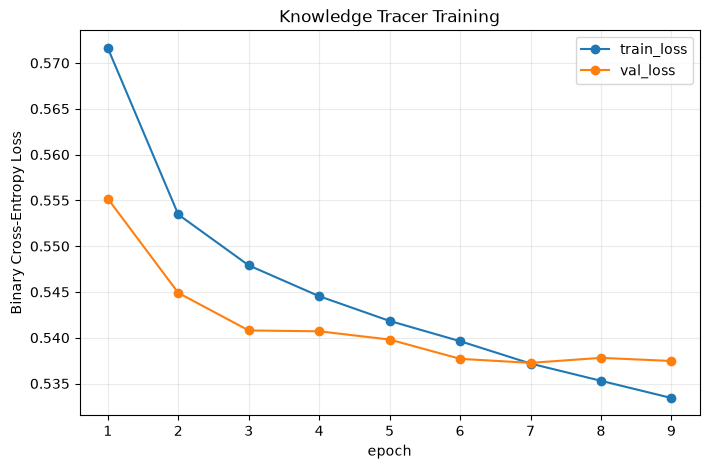

In [114]:
history_df = pd.DataFrame(training_history)

display(history_df.round(4))

ax = history_df.plot(
    x="epoch",
    y=[
        "train_loss",
        "val_loss",
    ],
    marker="o",
    figsize=(8, 5),
)

ax.set_title("Knowledge Tracer Training")

ax.set_ylabel("Binary Cross-Entropy Loss")

ax.grid(alpha=0.25)

Validation performance improves steadily during the first several epochs. The best checkpoint occurs at epoch 7, with about 0.5373 validation loss, 0.7362 accuracy, and 0.7576 ROC-AUC. Later, the validation loss stops improving while training loss continues to decrease, so early stopping prevents unnecessary additional fitting.


In [115]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("✓ Best validation model restored.")

✓ Best validation model restored.


The best model is saved at epoch 7.


In [116]:
(
  transformer_val_metrics,
  val_labels,
  transformer_val_probabilities,
) = evaluate_model(
   model,
  val_loader,
)

(
  transformer_test_metrics,
  test_labels,
  transformer_test_probabilities,
) = evaluate_model(
  model,
  test_loader,
)

global_test_probabilities = np.full(
  len(test_targets),
  global_correct_rate,
)

global_test_metrics = calculate_metrics(
  test_targets["correct"],
  global_test_probabilities,
)

skill_test_probabilities = (
  test_targets["skill_idx"]
  .map(skill_probability_lookup)
  .fillna(global_correct_rate)
  .to_numpy()
)

skill_test_metrics = calculate_metrics(
  test_targets["correct"],
  skill_test_probabilities,
)

test_results = pd.DataFrame(
  [
    {"model": "Global average", **global_test_metrics},
    {"model": "Skill difficulty", **skill_test_metrics},
    {"model": "Transformer knowledge tracer",
      **{
          key: value
          for key, value
          in transformer_test_metrics.items()
          if key != "loss"
        },
    },
  ]
)

display(test_results.round(4))

,model,accuracy,roc_auc,log_loss,brier
0,Global average,0.6761,0.5000,0.6302,0.2192
1,Skill difficulty,0.6788,0.6061,0.6130,0.2118
2,Transformer knowledge tracer,0.7366,0.7555,0.5303,0.1766


The Transformer clearly performs better than both simple baselines on the test students. Compared with the skill-difficulty baseline, test accuracy rises from 0.6788 to 0.7366 and ROC-AUC from 0.6061 to 0.7555, while the Brier score falls from 0.2118 to 0.1766.

This suggests that **the model is learning useful information from individual learning histories**, not only average difficulty differences among skills.


In [117]:
FINAL_MODEL_PATH = (MODEL_DIR / "adaptive_study_planner_model.pt")

torch.save(
    {
      # Model
      "model_state_dict": model.state_dict(),

      # Vocabulary
      "skill_to_idx": skill_to_idx,

      "idx_to_skill": idx_to_skill,

      # Model configuration
      "num_skills": NUM_SKILLS,

      "max_history": MAX_HISTORY,

      "d_model": D_MODEL,

      "n_heads": N_HEADS,

      "num_history_layers": NUM_HISTORY_LAYERS,

      "ff_dim": FF_DIM,

      "dropout": DROPOUT,

      # Preprocessing configuration
      "min_history": MIN_HISTORY,

      "pad_skill": PAD_SKILL,

      # Final validation performance
      "validation_metrics": transformer_val_metrics,
    },
    FINAL_MODEL_PATH,
)

print("✓ Final trained model saved to:")
print(FINAL_MODEL_PATH)

✓ Final trained model saved to:
/Users/miookuma/Downloads/models/adaptive_study_planner_model.pt


## 8. Student skill profile
The trained network successfully predicts on individual target interactions. To make those predictions useful for planning, I next convert one student's history into a current skill profile.

For one student, I prepare the same most recent history once and repeat it across all 89 candidate skills. Only `target_skill` changes. So the model estimates
$$
P(\text{correct on skill } s \mid \text{current student history})
$$
for every modeled skill.


In [118]:
def prepare_current_history(sequence, max_history=MAX_HISTORY):

    # Take the most recent interactions
    hist_skill = sequence["skill_idx"][-max_history:]

    hist_response = sequence["response_idx"][-max_history:]

    hist_type = sequence["type_idx"][-max_history:]

    history_length = len(hist_skill)

    pad_length = (max_history - history_length)

    # Left padding
    hist_skill = np.pad(
        hist_skill,
        (pad_length, 0),
        constant_values=0,
    )

    hist_response = np.pad(
        hist_response,
        (pad_length, 0),
        constant_values=0,
    )

    hist_type = np.pad(
        hist_type,
        (pad_length, 0),
        constant_values=0,
    )

    padding_mask = np.zeros(
        max_history,
        dtype=bool,
    )

    padding_mask[:pad_length] = True

    return {
        "hist_skill": torch.tensor(
            hist_skill,
            dtype=torch.long,
            device=DEVICE,
        ).unsqueeze(0),

        "hist_response": torch.tensor(
            hist_response,
            dtype=torch.long,
            device=DEVICE,
        ).unsqueeze(0),

        "hist_type": torch.tensor(
            hist_type,
            dtype=torch.long,
            device=DEVICE,
        ).unsqueeze(0),

        "padding_mask": torch.tensor(
            padding_mask,
            dtype=torch.bool,
            device=DEVICE,
        ).unsqueeze(0),

        "history_length": history_length,
    }

In [119]:
def estimate_skill_profile(model, sequence):

    history = prepare_current_history(sequence)

    skill_ids = np.array(
        sorted(idx_to_skill.keys()),
        dtype=np.int64,
    )

    num_queries = len(skill_ids)

    hist_skill = history["hist_skill"].repeat(num_queries, 1)

    hist_response = history["hist_response"].repeat(num_queries, 1)

    hist_type = history["hist_type"].repeat(num_queries, 1)

    padding_mask = history["padding_mask"].repeat(num_queries, 1)

    target_skill = torch.tensor(
        skill_ids,
        dtype=torch.long,
        device=DEVICE,
    )

    model.eval()

    with torch.inference_mode():

        logits = model(

            hist_skill=hist_skill,

            hist_response=hist_response,

            hist_type=hist_type,

            padding_mask=padding_mask,

            target_skill=target_skill,
        )

        probabilities = torch.sigmoid(logits).cpu().numpy()

    past_skills = sequence["skill_idx"]

    past_correct = sequence["correct"]

    rows = []

    for skill_idx, probability in zip(skill_ids, probabilities):
        
        positions = np.flatnonzero(
            past_skills == skill_idx
        )

        practice_count = len(positions)

        if practice_count > 0:

            last_position = positions[-1]

            interactions_since_last_seen = (
                len(past_skills)
                - 1
                - last_position
            )

            historical_accuracy = float(
                past_correct[
                    positions
                ].mean()
            )

        else:

            interactions_since_last_seen = np.nan

            historical_accuracy = np.nan

        rows.append(
            {
              "skill_idx": int(skill_idx),

              "skill_name": idx_to_skill[int(skill_idx)],

              "predicted_success": float(probability),

              "practice_count": int(practice_count),

              "historical_accuracy": historical_accuracy,

              "interactions_since_last_seen": interactions_since_last_seen,
            }
        )

    profile = pd.DataFrame(rows)

    return profile.sort_values(
        "predicted_success"
    ).reset_index(drop=True)

In [120]:
demo_candidates = [
    (
      user_id,
      len(sequence["skill_idx"]),
    )

    for user_id, sequence
    in test_sequences.items()

    if len(sequence["skill_idx"]) >= 30
]

demo_student_id, demo_history_length = min(

    demo_candidates,

    key=lambda item:
        abs(item[1] - 60),
)

demo_sequence = test_sequences[demo_student_id]

print("Demo student:", demo_student_id)

print("History length:", demo_history_length)

Demo student: 85024
History length: 60


This demonstration uses a held-out student with a history close to 60 interactions rather than searching for the student with the most impressive-looking output.


In [121]:
student_profile = estimate_skill_profile(model, demo_sequence,)

print("Lowest predicted-success skills:")

display(
    student_profile[
        [
            "skill_name",
            "predicted_success",
            "practice_count",
            "historical_accuracy",
            "interactions_since_last_seen",
        ]
    ]
    .head(15)
    .round(3)
)

Lowest predicted-success skills:


,skill_name,predicted_success,practice_count,historical_accuracy,interactions_since_last_seen
0,Rotations,0.075,0,NaN,NaN
1,Write Linear Equation from Graph,0.133,0,NaN,NaN
2,Finding Percents,0.178,0,NaN,NaN
3,Surface Area Cylinder,0.179,0,NaN,NaN
4,Percents,0.228,0,NaN,NaN
5,Equation Solving More Than Two Steps,0.237,0,NaN,NaN
6,Polynomial Factors,0.240,0,NaN,NaN
7,Effect of Changing Dimensions of a Shape Prpor...,0.243,0,NaN,NaN
8,Solving Systems of Linear Equations,0.255,0,NaN,NaN
9,Surface Area Rectangular Prism,0.255,0,NaN,NaN


This first raw profile reveals an important issue: the network can output a probability even for skills the demo student has never practiced. Those predictions may still reflect patterns learned during training, but they should not be presented as strongly personalized evidence. I address this later.

## 9. Adaptive study planner
The deep-learning model answers: how likely is the student to succeed on each skill? The planner answers the separate practical question: given deadlines, priorities, and limited time, what should the student study now?


In [122]:
candidate_skills = (
    student_profile.loc[
        student_profile[
            "practice_count"
        ] > 0
    ]
    .sort_values(
        "predicted_success"
    )
    .head(6)
    ["skill_name"]
    .tolist()
)

planner_inputs = pd.DataFrame(
    {
      "skill_name": candidate_skills,

      # Example user-provided constraints
      "days_until_deadline":
          [2, 4, 7, 10, 14, 21][
            :len(candidate_skills)
          ],

      # 1 = low importance
      # 5 = very important
      "importance":
          [5, 4, 4, 3, 3, 2][
            :len(candidate_skills)
          ],
    }
)

display(
    planner_inputs
)

,skill_name,days_until_deadline,importance
0,Rounding,2,5
1,Percent Of,4,4
2,Proportion,7,4
3,Ordering Positive Decimals,10,3
4,Conversion of Fraction Decimals Percents,14,3
5,Addition and Subtraction Fractions,21,2


This is an example of the input data given to the planner. Each skill has corresponding `days_until_deadline` and `importance` values.


### 9.1 Priority score
The planner merges model predictions with user-provided constraints. For each candidate skill, it computes
$$
\text{Priority} = 0.55W + 0.20D + 0.15I + 0.10R,
$$

where

- $W = 1-p$ is weakness, based on the Transformer's predicted success probability $p$
- $D = e^{-d/7}$ is deadline urgency for $d$ days until the deadline
- $I$ rescales user importance from 1–5 into 0–1
- $R$ increases when the skill has not been practiced recently.

The largest weight is placed on the learned model output, while the other terms make the recommendation responsive to the student's real constraints. These weights are transparent design choices, not learned parameters.


Also, the planner selects at most four high-priority skills, gives every selected skill at least 15-minute study time, and distributes the remaining time in 5-minute blocks according to priority. 

In [123]:
def calculate_study_priorities(student_profile, planner_inputs,):

    plan = planner_inputs.merge(
        student_profile,
        on="skill_name",
        how="left",
        validate="one_to_one",
    )

    plan["weakness"] = (1.0 - plan["predicted_success"])

    plan["deadline_urgency"] = np.exp(-plan["days_until_deadline"] / 7.0)

    plan["importance_score"] = (plan["importance"] - 1) / 4.0

    plan["recency_score"] = (
        plan["interactions_since_last_seen"]
        .fillna(20)
        .clip(
            lower=0,
            upper=20,
        )
        / 20.0
    )

    plan["priority_score"] = (
        0.55 * plan["weakness"]
        +
        0.20 * plan["deadline_urgency"]
        +
        0.15 * plan["importance_score"]
        +
        0.10 * plan["recency_score"]
    )

    return (
        plan
        .sort_values(
            "priority_score",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [124]:
def allocate_study_time(
    priority_table,
    total_minutes,
    max_skills=4,
    block_minutes=5,
    minimum_minutes=15,
):

    if total_minutes < minimum_minutes:

        raise ValueError(
            "Please provide at least "
            f"{minimum_minutes} study minutes."
        )

    # Number of skills we can reasonably study
    num_skills = min(
        max_skills,
        len(priority_table),
        max(1, total_minutes // minimum_minutes),
    )

    plan = (
        priority_table
        .head(num_skills)
        .copy()
    )

    total_blocks = (total_minutes // block_minutes)

    minimum_blocks = (minimum_minutes // block_minutes)

    # Give every selected skill a minimum study block.
    blocks = np.full(
        num_skills,
        minimum_blocks,
        dtype=int,
    )

    remaining_blocks = (total_blocks - blocks.sum())

    if remaining_blocks > 0:

        weights = (
            plan["priority_score"]
            / plan["priority_score"].sum()
        ).to_numpy()

        raw_extra = (weights * remaining_blocks)

        extra_blocks = np.floor(raw_extra).astype(int)

        blocks += extra_blocks

        leftover_blocks = (remaining_blocks - extra_blocks.sum())

        # Largest-remainder allocation
        remainders = (raw_extra - extra_blocks)

        order = np.argsort(-remainders)

        for index in order[:leftover_blocks]:

            blocks[index] += 1

    plan["study_minutes"] = (blocks * block_minutes)

    return plan

### 9.2 Recommend a study method
The recommended study method is intentionally simple. Lower predicted success leads to concept review and worked examples; moderate readiness leads to guided or mixed practice; high readiness leads to brief spaced review. The component is rule-based rather than learned, which keeps **the boundary between ML prediction and planning logic explicit**.


In [125]:
def recommend_study_method(row):

    p = row["predicted_success"]

    if row["practice_count"] == 0:
        return ("Diagnostic practice + concept overview")

    if p < 0.50:
        return ("Concept review + worked examples")

    elif p < 0.70:
        return ("Guided practice problems")

    elif p < 0.85:
        return ("Mixed practice + retrieval")

    else:
        return ("Brief spaced review")

In [126]:
AVAILABLE_MINUTES = 90

priority_table = (
    calculate_study_priorities(
        student_profile,
        planner_inputs,
    )
)

study_plan = (
    allocate_study_time(
        priority_table,
        total_minutes=AVAILABLE_MINUTES,
    )
)

study_plan[
    "recommended_method"
] = study_plan.apply(
    recommend_study_method,
    axis=1,
)

final_plan = study_plan[
    [
      "skill_name",
      "predicted_success",
      "priority_score",
      "study_minutes",
      "recommended_method",
      "days_until_deadline",
    ]
].copy()

final_plan[
    "predicted_success"
] = (
    final_plan[
        "predicted_success"
    ]
    * 100
)

print(
    f"Adaptive Study Plan "
    f"({AVAILABLE_MINUTES} minutes)"
)

display(
    final_plan.round(
        {
            "predicted_success": 1,
            "priority_score": 3,
        }
    )
)

Adaptive Study Plan (90 minutes)


,skill_name,predicted_success,priority_score,study_minutes,recommended_method,days_until_deadline
0,Rounding,44.5,0.705,25,Concept review + worked examples,2
1,Percent Of,47.7,0.613,25,Concept review + worked examples,4
2,Proportion,48.0,0.572,20,Concept review + worked examples,7
3,Conversion of Fraction Decimals Percents,51.6,0.468,20,Guided practice problems,14


The initial demonstration produces a complete 90-minute plan. Rounding receives the highest priority and 25 minutes of concept review, while the remaining time is distributed among the other high-priority skills.

## 10. Improve the study planner
A useful recommendation should not imply equal confidence for a skill practiced many times and a skill never seen by the student. I add evidence labels based on personal practice count.


In [127]:
def add_skill_evidence_labels(profile):

    profile = profile.copy()

    def evidence_level(count):
        if count == 0:
            return "unseen"
        elif count < 3:
            return "very limited"
        elif count < 5:
            return "limited"
        else:
            return "personalized"

    profile["evidence_level"] = (
        profile["practice_count"]
        .apply(evidence_level)
    )

    profile["personalized_estimate"] = (
        profile["practice_count"] >= 3
    )

    return profile

In [128]:
student_profile = add_skill_evidence_labels(
    student_profile
)

In [129]:
display(
    student_profile[
        [
          "skill_name",
          "predicted_success",
          "practice_count",
          "historical_accuracy",
          "evidence_level",
        ]
    ]
    .head(15)
    .round(3)
)

,skill_name,predicted_success,practice_count,historical_accuracy,evidence_level
0,Rotations,0.075,0,NaN,unseen
1,Write Linear Equation from Graph,0.133,0,NaN,unseen
2,Finding Percents,0.178,0,NaN,unseen
3,Surface Area Cylinder,0.179,0,NaN,unseen
4,Percents,0.228,0,NaN,unseen
5,Equation Solving More Than Two Steps,0.237,0,NaN,unseen
6,Polynomial Factors,0.240,0,NaN,unseen
7,Effect of Changing Dimensions of a Shape Prpor...,0.243,0,NaN,unseen
8,Solving Systems of Linear Equations,0.255,0,NaN,unseen
9,Surface Area Rectangular Prism,0.255,0,NaN,unseen


The evidence categories are:
- `unseen`: 0 personal interactions
- `very limited`: 1-2 interactions
- `limited`: 3-4 interactions
- `personalized`: at least 5 interactions

For this demonstration, I focus the displayed personalized profile on skills with at least three observed interactions, while still retaining the full profile internally.


In [130]:
personalized_profile = (
    student_profile.loc[
        student_profile["practice_count"] >= 3
    ]
    .sort_values(
        "predicted_success"
    )
    .reset_index(drop=True)
)

print("Personalized skill estimates:")

display(
    personalized_profile[
        [
          "skill_name",
          "predicted_success",
          "practice_count",
          "historical_accuracy",
          "interactions_since_last_seen",
          "evidence_level",
        ]
    ]
    .head(15)
    .round(3)
)

Personalized skill estimates:


,skill_name,predicted_success,practice_count,historical_accuracy,interactions_since_last_seen,evidence_level
0,Rounding,0.445,4,0.750,25.0,limited
1,Percent Of,0.477,6,0.333,39.0,personalized
2,Conversion of Fraction Decimals Percents,0.516,3,0.333,29.0,limited
3,Addition and Subtraction Fractions,0.521,4,0.500,6.0,limited
4,Addition and Subtraction Integers,0.581,6,0.667,54.0,personalized
5,Exponents,0.582,11,0.455,33.0,personalized
6,Equation Solving Two or Fewer Steps,0.720,16,0.562,0.0,personalized
7,Multiplication and Division Integers,0.825,3,1.000,8.0,limited


For the chosen held-out student, the displayed skill estimates range from limited to personalized evidence. For example, Percent Of has six prior interactions and a predicted success probability of about 0.477. The profile contains both a model estimate and information about how that estimate should be interpreted. 

## 11. End-to-end adaptive planner
The full study planner connects the project into one reusable pipeline:
1. estimate the student's current skill probabilities
2. attach evidence labels
3. combine the profile with user requirements
4. rank study priorities
5. allocate limited time
6. recommend a study method


In [131]:
def generate_study_plan(
    model,
    sequence,
    study_requirements,
    available_minutes=90,
):

    profile = estimate_skill_profile(model, sequence)

    profile = add_skill_evidence_labels(profile)

    priority_table = calculate_study_priorities(profile, study_requirements)

    final_plan = allocate_study_time(priority_table, total_minutes=available_minutes,)

    final_plan[
        "recommended_method"
    ] = final_plan.apply(
        recommend_study_method,
        axis=1,
    )

    return (
        profile,
        priority_table,
        final_plan,
    )

### 11.1 Example student request

In [132]:
demo_requirements = pd.DataFrame(
    {
      "skill_name": [
        "Percent Of",
        "Conversion of Fraction Decimals Percents",
        "Ordering Positive Decimals",
        "Rounding",
      ],

      "days_until_deadline": [
        2,
        4,
        7,
        10,
      ],

      "importance": [
        5,
        4,
        4,
        3,
      ],
    }
)

AVAILABLE_MINUTES = 90

display(demo_requirements)

,skill_name,days_until_deadline,importance
0,Percent Of,2,5
1,Conversion of Fraction Decimals Percents,4,4
2,Ordering Positive Decimals,7,4
3,Rounding,10,3


The example requests four relevant skills and provides their deadlines, importance levels, and a total study budget of 90 minutes.


In [133]:
(
  demo_profile,
  demo_priorities,
  demo_plan,
) = generate_study_plan(
  model=model,
  sequence=demo_sequence,
  study_requirements=demo_requirements,
  available_minutes=AVAILABLE_MINUTES,
)

In [134]:
final_demo = demo_plan[
  [
    "skill_name",
    "predicted_success",
    "priority_score",
    "study_minutes",
    "recommended_method",
    "days_until_deadline",
  ]
].copy()

final_demo[
    "predicted_success"
] *= 100

final_demo = final_demo.rename(
    columns={
      "skill_name": "Skill",

      "predicted_success": "Predicted Success (%)",

      "priority_score": "Priority",

      "study_minutes": "Minutes",

      "recommended_method": "Recommended Method",

      "days_until_deadline": "Days Until Deadline",
    }
)

display(
    final_demo.round(
      {
        "Predicted Success (%)": 1,
        "Priority": 3,
      }
    )
)

,Skill,Predicted Success (%),Priority,Minutes,Recommended Method,Days Until Deadline
0,Percent Of,47.7,0.688,25,Concept review + worked examples,2
1,Conversion of Fraction Decimals Percents,51.6,0.592,25,Guided practice problems,4
2,Rounding,44.5,0.528,20,Concept review + worked examples,10
3,Ordering Positive Decimals,48.2,0.506,20,Concept review + worked examples,7


The final plan assigns 25, 25, 20, and 20 minutes to the four requested skills. It also gives a recommended study method for each skill.


In [135]:
allocated_minutes = (
    demo_plan[
        "study_minutes"
    ].sum()
)

print("Requested study time:", AVAILABLE_MINUTES)

print("Allocated study time:", allocated_minutes)

assert (allocated_minutes <= AVAILABLE_MINUTES)

assert (
  demo_plan[
    "study_minutes"
  ] > 0
).all()

assert (
  demo_plan[
    "priority_score"
  ]
  .is_monotonic_decreasing
)

print("\n✓ Study-time constraint satisfied.")

print("✓ Every selected skill receives time.")

print("✓ Skills are ranked by priority.")

Requested study time: 90
Allocated study time: 90

✓ Study-time constraint satisfied.
✓ Every selected skill receives time.
✓ Skills are ranked by priority.


These sanity checks verify that the planner never exceeds the requested budget, every selected skill receives positive study time, and the output remains sorted by priority.


## 12. Main findings
1. **Sequential student history adds predictive value.** The Transformer knowledge tracer performs better than a baseline that knows only average skill difficulty.

2. **The query-based architecture supports skill-specific planning.** The same student history can be queried with different target skills, producing a full profile rather than one generic student score.

3. **Probability quality matters for recommendations.** The Transformer improves not only thresholded accuracy but also ROC-AUC, log loss, and Brier score, which is important because the planner uses the probability itself as a measure of weakness.

4. **Prediction and planning are separated.** The Transformer learns from educational sequences, while study-method rules are explicit planner logic. This keeps the system understandable and avoids claiming that unsupported decisions were learned from the dataset.


## 13. Limitations
1. The ASSISTments data represents online math practice, so the results do not automatically generalize to other subjects or university-level coursework.

2. The model predicts the probability of the next response being correct. This is a useful approximation for skill readiness, but it is not a direct measurement of whether a study recommendation improves learning.

3. The maximum history is 100 events. This captures recent behavior efficiently but can discard older evidence for students with very long histories.

4. Low-data skills are excluded, leaving 89 modeled skills. The planner therefore cannot provide learned predictions for every concept in the raw dataset.

5. Deadline importance, priority weights, time allocation, and study-method thresholds are manually designed. They have not been optimized from student outcomes.

6. The final planner is demonstrated on held-out historical data. It is not yet evaluated through a live intervention where students follow the plan and later learning gains are measured.

## 14. Future work
Potential extensions would be:
- add uncertainty analysis so low-confidence skill estimates can be treated more cautiously
- learn and tune the planning weights from later student outcomes rather than choosing them manually
- allow richer user constraints such as course schedules and preferred study methods
- evaluate the planner prospectively by measuring whether following its recommendations improves later performance

These extensions would move the project from an offline adaptive-planning prototype toward a more realistic personalized learning assistant.


## 15. Conclusion
This project builds an end-to-end **Adaptive Study Planner** from sequential educational data. A query-based Transformer models each student's recent learning history and estimates skill-specific success probabilities. On held-out students, the model reaches **0.7555 ROC-AUC** and outperforms the global-average and skill-difficulty baselines.

The project then goes beyond prediction by converting the learned skill profile into a study plan under real constraints. Model-estimated weakness is combined with deadlines, importance, review recency, and a fixed time budget to decide what to study, how long to study it, and what type of method to use.

The most important design choice is the separation between the **learned knowledge tracer** and the **transparent planning layer**. The model supplies personalized evidence, then the planner turns that evidence into a transparent study schedule. This creates a practical deep-learning system.
